In [48]:
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import scipy.io
import pandas as pd


data = scipy.io.loadmat("annthyroid.mat")
print(data.keys())  # Bu orqali asosiy kalitlarni ko'ramiz


X = data['X']          
y = data['y'].ravel()   


df = pd.DataFrame(X)
df['label'] = y


df.to_csv("annthyroid_dataset.csv", index=False)
print("CSV saqlandi: annthyroid_dataset.csv")


dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])
CSV saqlandi: annthyroid_dataset.csv


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       7200 non-null   float64
 1   1       7200 non-null   float64
 2   2       7200 non-null   float64
 3   3       7200 non-null   float64
 4   4       7200 non-null   float64
 5   5       7200 non-null   float64
 6   label   7200 non-null   uint8  
dtypes: float64(6), uint8(1)
memory usage: 344.7 KB


In [67]:
df.head()

,0,1,2,3,4,5,label
0,0.73,0.00060,0.015,0.120,0.082,0.146,0
1,0.24,0.00025,0.030,0.143,0.133,0.108,0
2,0.47,0.00190,0.024,0.102,0.131,0.078,0
3,0.64,0.00090,0.017,0.077,0.090,0.085,0
4,0.23,0.00025,0.026,0.139,0.090,0.153,0


In [68]:
x = df[['label']]
y = df['label']


In [69]:
from sklearn.ensemble import IsolationForest
iso_forest = IsolationForest(
    n_estimators=100,
    max_samples='auto',
    contamination=0.1,  
    random_state=42
)


iso_forest.fit(x)


IsolationForest(contamination=0.1, random_state=42)

In [70]:

y_pred = iso_forest.predict(x)

y_pred = [1 if x == -1 else 0 for x in y_pred]


In [71]:
y_pred

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [72]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.1, random_state=42)
df['predicted_label'] = model.fit_predict(df[['label']])

In [73]:
df['predicted_label'] = df['predicted_label'].apply(lambda x: 0 if x == 1 else 1)

In [78]:
print(df.columns.tolist())

[0, 1, 2, 3, 4, 5, 'label', 'predicted_label']


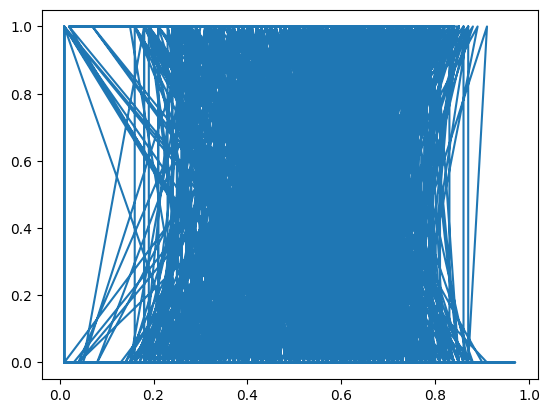

In [77]:
plt.plot(df.iloc[:, 0], df['label']) 

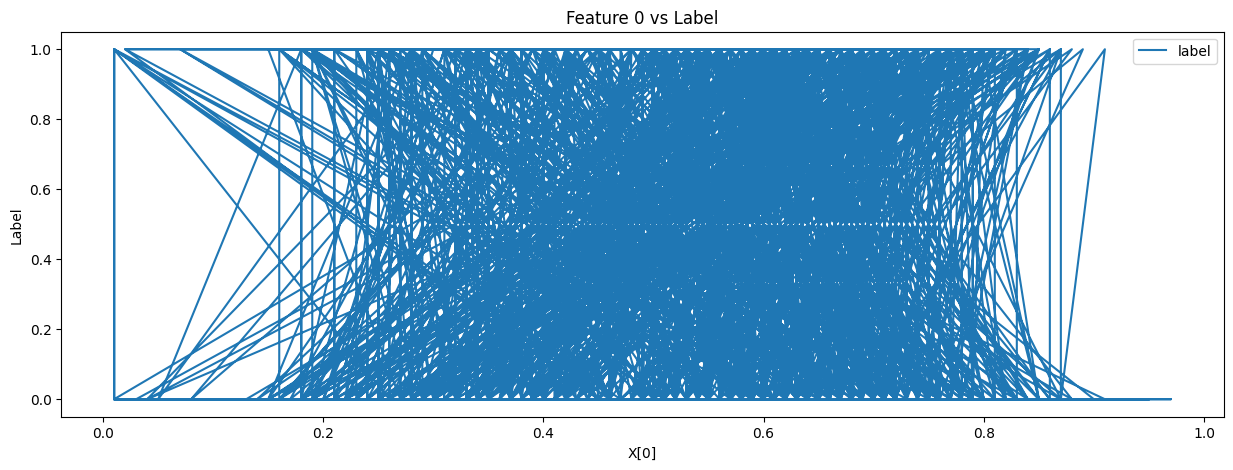

In [ ]:
import scipy.io
import pandas as pd
import matplotlib.pyplot as plt


data = scipy.io.loadmat("annthyroid.mat")
X = data['X']
y = data['y'].ravel()


df = pd.DataFrame(X)
df['label'] = y


df.columns = df.columns.astype(str)


plt.figure(figsize=(15, 5))
plt.plot(df['0'], df['label'], label='label')
plt.title("Feature 0 vs Label")
plt.xlabel("X[0]")
plt.ylabel("Label")
plt.legend()
plt.show()



In [80]:
print(df.columns)

Index(['0', '1', '2', '3', '4', '5', 'label'], dtype='object')


In [82]:
from sklearn.ensemble import IsolationForest


X = df.drop('label', axis=1)


model = IsolationForest(contamination=0.02, random_state=42)
model.fit(X)

predictions = model.predict(X)  


df['predicted_label'] = [1 if p == -1 else 0 for p in predictions]


In [83]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))

Confusion Matrix:
[[6666    0]
 [   0  534]]

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      6666
           1     1.0000    1.0000    1.0000       534

    accuracy                         1.0000      7200
   macro avg     1.0000    1.0000    1.0000      7200
weighted avg     1.0000    1.0000    1.0000      7200



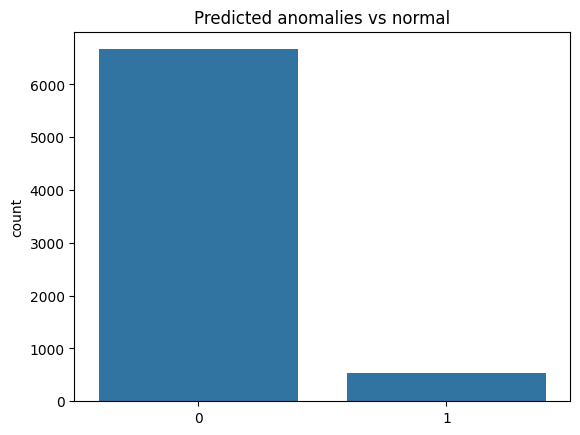

In [84]:
import seaborn as sns
sns.countplot(x=y_pred)
plt.title("Predicted anomalies vs normal")
plt.show()


In [89]:
print(df.columns.tolist())

['0', '1', '2', '3', '4', '5', 'label', 'predicted_label']


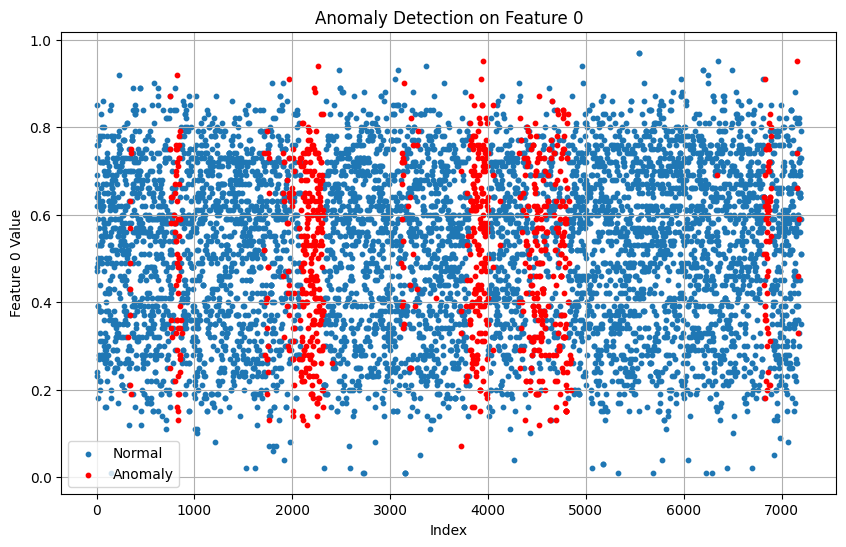

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Normal nuqtalar
plt.scatter(df.index[df['predicted_label'] == 0], df['0'][df['predicted_label'] == 0], label="Normal", s=10)

# Anomaliyalar
plt.scatter(df.index[df['predicted_label'] == 1], df['0'][df['predicted_label'] == 1], label="Anomaly", s=10, color='red')

plt.legend()
plt.title("Anomaly Detection on Feature 0")
plt.xlabel("Index")
plt.ylabel("Feature 0 Value")
plt.grid(True)
plt.show()




In [91]:
df['anomaly'] = y_pred_series


anomalies = df[df['anomaly'] == 1]


print("Number of detected anomalies:", anomalies.shape[0])
print(anomalies.head())


Number of detected anomalies: 940
        0        1       2        3      4        5  label  predicted_label  \
323  0.32  0.00189  0.0206  0.11118  0.099  0.11207      0                1   
341  0.57  0.00120  0.0140  0.11800  0.102  0.11600      0                1   
342  0.43  0.00150  0.0120  0.07800  0.072  0.10800      0                1   
344  0.63  0.00110  0.0230  0.09000  0.088  0.10200      0                1   
345  0.49  0.00010  0.0030  0.03200  0.052  0.06000      0                1   

     anomaly  
323        1  
341        1  
342        1  
344        1  
345        1  


In [92]:
anomalies.to_csv('aniqlangan_anomalies.csv', index=False)
print("Anomaly cases saved to aniqlangan_anomalies.csv")


Anomaly cases saved to aniqlangan_anomalies.csv


In [94]:
df['Anomaly_Label'] = df['predicted_label'].map({0: 'Normal', 1: 'Anomaly'})


print(df[['0', 'Anomaly_Label']].head(200))



        0 Anomaly_Label
0    0.73        Normal
1    0.24        Normal
2    0.47        Normal
3    0.64        Normal
4    0.23        Normal
..    ...           ...
195  0.49        Normal
196  0.71        Normal
197  0.34        Normal
198  0.29        Normal
199  0.69        Normal

[200 rows x 2 columns]
